In [ ]:
# Chatbot Data Validation & EDA
Validating the structured output generated by the Sarvam AI extraction pipeline before importing it into Tableau.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# loading the extracted chatbot data csv
df = pd.read_csv('chatbot_data.csv')

In [3]:
# checking of the data dimensions and types
print("Data shape:", df.shape)
df.info()

Data shape: (1000, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Interaction_ID         1000 non-null   int64
 1   Customer_ID            1000 non-null   int64
 2   Date                   1000 non-null   str  
 3   Customer_Intent        1000 non-null   str  
 4   Chat_Duration_Seconds  1000 non-null   int64
 5   Customer_Sentiment     1000 non-null   str  
 6   Resolution_Status      1000 non-null   str  
dtypes: int64(3), str(4)
memory usage: 39.1 KB


In [ ]:
### Missing Values Check
Because the data was extracted using a strictly prompted LLM pipeline, the output should be completely clean with zero null values.

In [4]:
print(df.isnull().sum())

Interaction_ID           0
Customer_ID              0
Date                     0
Customer_Intent          0
Chat_Duration_Seconds    0
Customer_Sentiment       0
Resolution_Status        0
dtype: int64


In [5]:
# fixing the Date column - needs to be datetime for Tableau time-series charts
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
# quick preview before moving to visualization
df.head()

,Interaction_ID,Customer_ID,Date,Customer_Intent,Chat_Duration_Seconds,Customer_Sentiment,Resolution_Status
0,1,926,2026-06-01 00:00:00,Product Inquiry,146,Positive,Pending
1,2,376,2026-06-01 01:00:00,Billing Issue,87,Neutral,Pending
2,3,378,2026-06-01 02:00:00,Technical Support,479,Negative,Escalated to Human
3,4,372,2026-06-01 03:00:00,Technical Support,116,Positive,Escalated to Human
4,5,212,2026-06-01 04:00:00,Technical Support,442,Neutral,Resolved


In [ ]:
### Quick EDA & Sanity Checks
Just taking a quick look at the distributions before moving this over to Tableau.

In [7]:
# checking chat duration stats
df['Chat_Duration_Seconds'].describe().round(1)

count    1000.0
mean      309.2
std       164.3
min        30.0
25%       163.8
50%       311.0
75%       454.0
max       599.0
Name: Chat_Duration_Seconds, dtype: float64

In [8]:
# checking what users are actually asking about
display(df['Customer_Intent'].value_counts())

Customer_Intent
Product Inquiry      223
Refund Request       201
Technical Support    199
Password Reset       194
Billing Issue        183
Name: count, dtype: int64

In [9]:
# checking overall sentiment
display(df['Customer_Sentiment'].value_counts())

Customer_Sentiment
Neutral     340
Positive    336
Negative    324
Name: count, dtype: int64

<Axes: title={'center': 'Resolution Status'}, xlabel='Resolution_Status'>

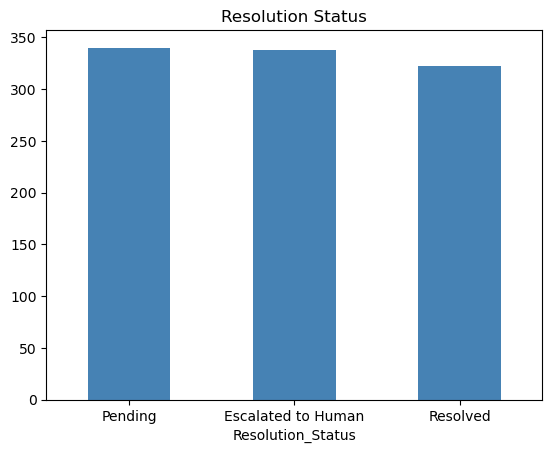

In [12]:
# quick plot to see how many tickets are resolved vs pending
df['Resolution_Status'].value_counts().plot(
    kind='bar', 
    title='Resolution Status', 
    color='steelblue', 
    rot=0
)

<Axes: title={'center': 'Distribution of Chat Durations (Seconds)'}, ylabel='Frequency'>

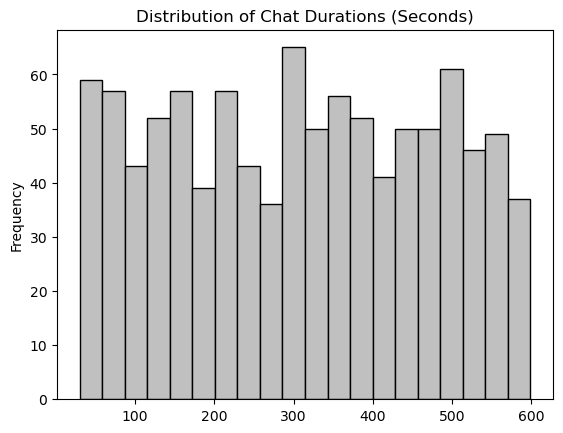

In [13]:
# checking the spread of chat times (are most chats quick or long?)
df['Chat_Duration_Seconds'].plot(
    kind='hist', 
    bins=20, 
    title='Distribution of Chat Durations (Seconds)',
    color='silver',
    edgecolor='black'
)

In [ ]:
### Deeper Insights (Cross-Analysis)
Looking at how different variables interact with each other.

In [14]:
# see which types of intents take the longest on average
display(df.groupby('Customer_Intent')['Chat_Duration_Seconds'].mean().round(1).sort_values(ascending=False))

Customer_Intent
Product Inquiry      311.8
Billing Issue        311.7
Password Reset       310.7
Refund Request       308.4
Technical Support    303.4
Name: Chat_Duration_Seconds, dtype: float64

In [15]:
# checking if negative sentiment leads to more human escalations
pd.crosstab(df['Customer_Sentiment'], df['Resolution_Status'])

Resolution_Status,Escalated to Human,Pending,Resolved
Customer_Sentiment,,,
Negative,121,109,94
Neutral,105,115,120
Positive,112,116,108
